# 패키지 및 데이터

In [37]:
from hossam import *
from pandas import concat 
from pycaret.regression import *

### 데이터

In [38]:
origin = load_data("restaurant_sales_preprocessed")
origin.head()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)


,date,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
0,2024-01-01,16.169,122,14490,9.200,0.480,1.946,5.200,0,0
1,2024-01-02,16.005,106,11880,9.149,0.480,2.079,11.100,0,0
2,2024-01-03,16.354,120,18010,8.666,0.430,2.595,12.900,1,0
3,2024-01-04,16.082,115,11160,8.748,0.410,2.028,12.900,0,0
4,2024-01-05,16.113,124,15480,8.594,0.510,2.197,11.000,0,0


### 카테고리로 dtype 변환

In [39]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("int")
origin["weekend"] = origin["weekend"].astype("int")
origin.info()



어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sales           353 non-null    float64
 1   visitors        353 non-null    int64  
 2   avg_price       353 non-null    int64  
 3   marketing_cost  353 non-null    float64
 4   delivery_ratio  353 non-null    float64
 5   rain_mm         353 non-null    float64
 6   temperature     353 non-null    float64
 7   holiday         353 non-null    int64  
 8   weekend         353 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 27.6 KB


# PyCaretsetup

### setup()

In [28]:
s = RegressionExperiment()
s.setup(data=origin, target, **options)

SyntaxError: positional argument follows keyword argument (2412585119.py, line 2)

In [29]:
# setup클래스에 전달할 객체(인스턴트) 생성
s = RegressionExperiment()
# RegressioinExperiment: 클래스

# setup():인스턴트 메서드
s.setup(
# ----------------------------------
# 기본 설정(필수 지정)
# ----------------------------------

# 데이터셋 지정
data = origin,

# 예측 목표 변수 지정
target = "sales",

# 랜덤 시드 고정
session_id =52,

# 훈련 데이터 비율(기본값=0.7)
train_size = 0.75,

# 교차검증 폴드 수 지정
fold = 5,

# 처리 과정 출력 안함(기본값 True, False 권장. 출력 과정이 다소 길어질 수 있음)
verbose = False,

# GPU 사용 여부 지정
use_gpu = False,

# ----------------------------------
# 전처리 설정(1)
# ----------------------------------

categorical_features = ['weekend', 'holiday'],

# 생략할 변수 지정(기본값None)
ignore_features = [],

# 데이터 정규화/표준화 활성화(기본값 False)
normalize = True,

# 데이터 정규화/표준화 방법 선택(zscore가 StandardScaler와 동일)
# 'minmax', 'maxabs','robust', 'zscore'
normalize_method = 'zscore',

# ----------------------------------
# 전처리 설정(2) - 아래 기능은 사용하지 말고, 데이터 별도의 전처리 단계를 거치는 것을 권장 
# ----------------------------------

# 이상치 제거(기본값False, IQR 범위 밖의 값을 삭제함)
remove_outliers = False,

# 이상치 제거 임계값(기본값 0.05, 상하위 몇%를 이상치로 간주할지 지정)
outliers_threshold=0.05,

# 종속변수 변환(기본값False)
transform_target = False,

# 변수 선택(기본값False)
feature_selection = False
)

### Setup 결과 확인

In [30]:
s.pull()

,Description,Value
0,Session id,52
1,Target,sales
2,Target type,Regression
3,Original data shape,"(353, 9)"
4,Transformed data shape,"(353, 9)"
5,Transformed train set shape,"(264, 9)"
6,Transformed test set shape,"(89, 9)"
7,Numeric features,6
8,Categorical features,2
9,Preprocess,True


# 단일 모형 구축

### 사용할 수 있는 학습 모델의 종류 확인

In [24]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.ElasticNet,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPursuit,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


### 기본 파라미터로 학습하기

In [25]:
model = s.create_model("rf")
model

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3110,0.1638,0.4047,-0.0881,0.0231,0.0188
1,0.3778,0.1990,0.4461,-0.1250,0.0256,0.0230
2,0.3510,0.1739,0.4170,-0.0927,0.0240,0.0214
3,0.2851,0.1303,0.3610,-0.1310,0.0208,0.0175
4,0.3285,0.1475,0.3841,-0.2272,0.0221,0.0201
Mean,0.3307,0.1629,0.4026,-0.1328,0.0231,0.0202
Std,0.0319,0.0233,0.0289,0.0502,0.0016,0.0019


RandomForestRegressor(n_jobs=-1, random_state=52)

# 하이퍼파라미터 튜닝 학습 모델 생성

In [ ]:
### 

In [ ]:
# ── 서드파티 라이브러리
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame, Series

np.random.seed(42)

d = np.column_stack([
    np.random.normal(50,10,100),  #평균, 표준편차, 데이터수
    np.random.normal(60,20,100),
    np.random.randint(30,50,100),
    np.random.randint(35,40,100)
])

df = DataFrame(
    d,
    columns = ["a","b","c","d"]
)

df


,a,b,c,d
0,54.967,31.693,31.000,36.000
1,48.617,51.587,46.000,35.000
2,56.477,53.146,37.000,38.000
3,65.230,43.954,30.000,37.000
4,47.658,56.774,38.000,38.000
5,47.659,68.081,40.000,38.000
6,65.792,97.724,45.000,36.000
7,57.674,63.492,36.000,37.000
8,45.305,65.151,39.000,38.000
9,55.426,58.511,32.000,35.000


In [4]:
df = DataFrame(
    d,
    columns = ["a","b","c","d"],
    index = range(1000,1100)
)
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 1000 to 1099
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       100 non-null    float64
 1   b       100 non-null    float64
 2   c       100 non-null    float64
 3   d       100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


### 기존 데이터에 새로운 인덱스 부여

In [ ]:
df.index = range(1,101)
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 1 to 100
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       100 non-null    float64
 1   b       100 non-null    float64
 2   c       100 non-null    float64
 3   d       100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


### 인덱스를 "칼럼으로 추가" 하고 싶을 때

In [ ]:
df = df.reset_index()
df.head()

,index,a,b,c,d
0,1,54.967,31.693,31.000,36.000
1,2,48.617,51.587,46.000,35.000
2,3,56.477,53.146,37.000,38.000
3,4,65.230,43.954,30.000,37.000
4,5,47.658,56.774,38.000,38.000


### 특정 칼럼을 인덱스로 설정

In [49]:
df = df.set_index("a")
df.head()

,b,c,d
a,,,
54.967,31.693,31.000,36.000
48.617,51.587,46.000,35.000
56.477,53.146,37.000,38.000
65.230,43.954,30.000,37.000
47.658,56.774,38.000,38.000


### reset_index()

In [96]:
# ── 서드파티 라이브러리
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame, Series

np.random.seed(42)

d_1 = np.column_stack([
    np.random.normal(50,30,100),  #평균, 표준편차, 데이터수
    np.random.normal(60,30,100),
    np.random.randint(30,50,100),
    np.random.randint(35,40,100)
])

df1 = DataFrame(
    d_1,
    columns = ["a","b","c","d"]
)

df1.head()


,a,b,c,d
0,64.901,17.539,31.000,36.000
1,45.852,47.381,46.000,35.000
2,69.431,49.719,37.000,38.000
3,95.691,35.932,30.000,37.000
4,42.975,55.161,38.000,38.000


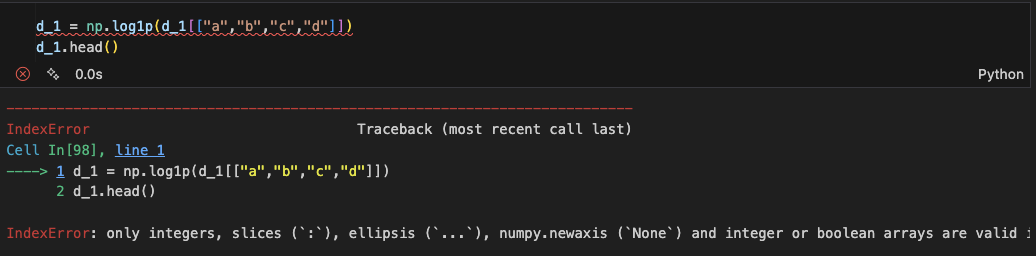<br>
> d_1이 DataFrame이 아니라 NumPy배열이여서 에러<br>
> NumPy 배열이면 그냥 전체에 log 적용



In [ ]:
type(d_1)


numpy.ndarray

In [102]:
d_1 = pd.DataFrame(d_1, columns=["a","b","c","d"])
d_1 = np.log1p(d_1[["a","b","c","d"]])
d_1.head()

,a,b,c,d
0,0.973,0.861,0.915,0.928
1,0.947,0.950,0.947,0.925
2,0.978,0.953,0.930,0.932
3,1.000,0.927,0.912,0.930
4,0.942,0.961,0.932,0.932


In [98]:
d_1 = np.log1p(d_1[["a","b","c","d"]])
d_1.head()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

# 인덱스를 칼럼으로 추가 

In [56]:
df1 = df1.reset_index()
df1.head()

,index,a,b,c,d
0,0,64.901,17.539,31.000,36.000
1,1,45.852,47.381,46.000,35.000
2,2,69.431,49.719,37.000,38.000
3,3,95.691,35.932,30.000,37.000
4,4,42.975,55.161,38.000,38.000


### 실습

In [57]:
df1 = df1.rename(columns = {"index":"Hello"})
df1.head()

,Hello,a,b,c,d
0,0,64.901,17.539,31.000,36.000
1,1,45.852,47.381,46.000,35.000
2,2,69.431,49.719,37.000,38.000
3,3,95.691,35.932,30.000,37.000
4,4,42.975,55.161,38.000,38.000


In [ ]:
# 에러 원인: inplace = True를 사용하면, df1에서 수정됨
df2 = df1.rename(columns = {"Hello":"Hi"}, inplace = True)
df2.head()


AttributeError: 'NoneType' object has no attribute 'head'

In [1]:
import pandas as pd
origin = pd.read_csv("/Users/gyulltang/Desktop/vscode/ipynb/12월/실습/260210 복습/OnlineRetail.csv", encoding= "latin1")
origin.info()
origin.head()
origin.shape

FileNotFoundError: [Errno 2] No such file or directory: '/Users/gyulltang/Desktop/vscode/ipynb/12월/실습/260210 복습/OnlineRetail.csv'

### 실습

In [60]:
df= origin.copy()

# reset_index()를 통해 index라는 열이 생김
# rename()i을 사용하여 ndex칼럼을 ID로 바꿨다
df = df.reset_index().rename(columns ={"index":"ID"})
df

,ID,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,17850.000,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,17850.000,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.850,12680.000,France
541905,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.100,12680.000,France
541906,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.150,12680.000,France
541907,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.150,12680.000,France


In [66]:
# rename(columns={})에는 딕셔너리 하나만 들어갈 수 있다
df = df.rename(columns={"Quantity":"양"})
df = df.rename(columns={"InvoiceDate":"구매시각"})
df.head()


,ID,InvoiceNo,StockCode,Description,양,구매시각,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,17850.000,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,17850.000,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,17850.000,United Kingdom


In [69]:
# 한 딕셔너리에 같이 작성
df = df.rename(columns = {
    "quantity":"양",
    "InvoiceDate":"구매시간"
})
df

,ID,InvoiceNo,StockCode,Description,양,구매시각,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,17850.000,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,17850.000,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.850,12680.000,France
541905,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.100,12680.000,France
541906,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.150,12680.000,France
541907,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.150,12680.000,France


# method chaing

In [ ]:
# 전처리 체이닝

df = (
    df.rename(columns={
        "양":"quantity",
        "구매시각":"invoice_date"
    })
    .assign(
        sales = lambda x: x["quantity"] * x["UnitPrice"]
    )
).dropna()

df

,ID,InvoiceNo,StockCode,Description,quantity,invoice_date,UnitPrice,CustomerID,Country,sales
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,17850.000,United Kingdom,15.300
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,17850.000,United Kingdom,20.340
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,17850.000,United Kingdom,22.000
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,17850.000,United Kingdom,20.340
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,17850.000,United Kingdom,20.340
...,...,...,...,...,...,...,...,...,...,...
541904,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.850,12680.000,France,10.200
541905,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.100,12680.000,France,12.600
541906,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.150,12680.000,France,16.600
541907,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.150,12680.000,France,16.600


In [ ]:
df1 = df.copy()
df1["UnitPrice"] = df["UnitPrice"].apply(lambda x:x + 10)

df1["UnitPrice"]

compare_df = pd.DataFrame(
    {
        "before":df["UnitPrice"],
        "after" : df1["UnitPrice"],
        "mean":df1["UnitPrice"].mean(),
        "max": df1["UnitPrice"].max(),
        "왜도(skewness)":df1["UnitPrice"].skew(),
        "첨도(kurtosis)" : df1["UnitPrice"].kurt(),
        
    }
)

compare_df.head()


,before,after,mean,max,왜도(skewness),첨도(kurtosis)
0,3.550,13.550,14.460,38981.000,452.219,246924.543
1,4.390,14.390,14.460,38981.000,452.219,246924.543
2,3.750,13.750,14.460,38981.000,452.219,246924.543
3,4.390,14.390,14.460,38981.000,452.219,246924.543
4,4.390,14.390,14.460,38981.000,452.219,246924.543


In [90]:
# 요약 통계 전용
summary_df = pd.DataFrame({
    "mean": [df1["UnitPrice"].mean()],
    "max": [df1["UnitPrice"].max()],
    "skew": [df1["UnitPrice"].skew()],
    "kurtosis": [df1["UnitPrice"].kurt()]
})

summary_df


,mean,max,skew,kurtosis
0,14.460,38981.000,452.219,246924.543


In [93]:
stats = df1["UnitPrice"].agg(
    ["mean", "max", "skew", "kurt"]
)
stats

mean       14.460
max     38981.000
skew      452.219
kurt   246924.543
Name: UnitPrice, dtype: float64

In [94]:
summary_compare = pd.DataFrame({
    "before": df["UnitPrice"].agg(["mean", "max", "skew", "kurt"]),
    "after": df1["UnitPrice"].agg(["mean", "max", "skew", "kurt"])
})

summary_compare


,before,after
mean,4.460,14.460
max,38971.000,38981.000
skew,452.219,452.219
kurt,246924.543,246924.543
